In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/sales_clean.csv", low_memory=False)

In [3]:
df["order_date"] = pd.to_datetime(df["order_date"])
df["Customer Since"] = pd.to_datetime(df["Customer Since"])

In [4]:
df[["order_date", "Customer Since"]].dtypes

order_date        datetime64[ns]
Customer Since    datetime64[ns]
dtype: object

**Create Order Month**

In [5]:
df["OrderMonth"] = df["order_date"].dt.to_period("M")

In [6]:
df[["order_date", "OrderMonth"]].head()

,order_date,OrderMonth
0,2020-10-01,2020-10
1,2020-10-01,2020-10
2,2020-10-01,2020-10
3,2020-10-01,2020-10
4,2020-11-13,2020-11


_Find Customer's First Purchase Month_

In [7]:
cohort = df.groupby("cust_id")["OrderMonth"].min().reset_index()
cohort.columns = ["cust_id", "CohortMonth"]

cohort.head()

,cust_id,CohortMonth
0,4,2020-12
1,15,2020-10
2,20,2021-03
3,21,2021-02
4,23,2021-02


In [8]:
df = df.merge(cohort, on="cust_id")
df[["cust_id", "OrderMonth", "CohortMonth"]].head()

,cust_id,OrderMonth,CohortMonth
0,60124,2020-10,2020-10
1,60124,2020-10,2020-10
2,60124,2020-10,2020-10
3,60124,2020-10,2020-10
4,60124,2020-11,2020-10


**Create Cohort Index**

In [9]:
df["CohortIndex"] = (
    (df["OrderMonth"].dt.year - df["CohortMonth"].dt.year) * 12 +
    (df["OrderMonth"].dt.month - df["CohortMonth"].dt.month) + 1
)
df[["cust_id", "OrderMonth", "CohortMonth", "CohortIndex"]].head(10)

,cust_id,OrderMonth,CohortMonth,CohortIndex
0,60124,2020-10,2020-10,1
1,60124,2020-10,2020-10,1
2,60124,2020-10,2020-10,1
3,60124,2020-10,2020-10,1
4,60124,2020-11,2020-10,2
5,60124,2020-11,2020-10,2
6,42485,2020-12,2020-12,1
7,42485,2020-12,2020-12,1
8,42485,2020-12,2020-12,1
9,42485,2020-12,2020-12,1


_Create the Retention Matrix_

In [10]:
cohort_data = (
    df.groupby(["CohortMonth", "CohortIndex"])["cust_id"]
      .nunique()
      .reset_index()
)

cohort_data.head()

,CohortMonth,CohortIndex,cust_id
0,2020-10,1,1822
1,2020-10,2,306
2,2020-10,3,381
3,2020-10,4,169
4,2020-10,5,123


_Create the Cohort Matrix_

In [11]:
cohort_counts = cohort_data.pivot(
    index="CohortMonth",
    columns="CohortIndex",
    values="cust_id"
)

cohort_counts

cohort_counts.columns = [
    f"Month {i-1}" for i in cohort_counts.columns
]

cohort_counts.head()

,Month 0,Month 1,Month 2,Month 3,Month 4,Month 5,Month 6,Month 7,Month 8,Month 9,Month 10,Month 11
CohortMonth,,,,,,,,,,,,
2020-10,1822.0,306.0,381.0,169.0,123.0,177.0,151.0,88.0,143.0,85.0,54.0,80.0
2020-11,2522.0,562.0,211.0,135.0,204.0,178.0,106.0,188.0,82.0,47.0,82.0,NaN
2020-12,14020.0,1011.0,458.0,632.0,675.0,328.0,559.0,262.0,168.0,250.0,NaN,NaN
2021-01,2369.0,159.0,110.0,113.0,71.0,81.0,65.0,43.0,48.0,NaN,NaN,NaN
2021-02,1412.0,123.0,96.0,53.0,53.0,33.0,27.0,27.0,NaN,NaN,NaN,NaN


_Retention Percentage_

In [12]:
retention = cohort_counts.divide(
    cohort_counts["Month 0"], axis=0
) * 100

retention = retention.round(2)

retention.head()

,Month 0,Month 1,Month 2,Month 3,Month 4,Month 5,Month 6,Month 7,Month 8,Month 9,Month 10,Month 11
CohortMonth,,,,,,,,,,,,
2020-10,100.0,16.79,20.91,9.28,6.75,9.71,8.29,4.83,7.85,4.67,2.96,4.39
2020-11,100.0,22.28,8.37,5.35,8.09,7.06,4.20,7.45,3.25,1.86,3.25,NaN
2020-12,100.0,7.21,3.27,4.51,4.81,2.34,3.99,1.87,1.20,1.78,NaN,NaN
2021-01,100.0,6.71,4.64,4.77,3.00,3.42,2.74,1.82,2.03,NaN,NaN,NaN
2021-02,100.0,8.71,6.80,3.75,3.75,2.34,1.91,1.91,NaN,NaN,NaN,NaN


_Heatmap_

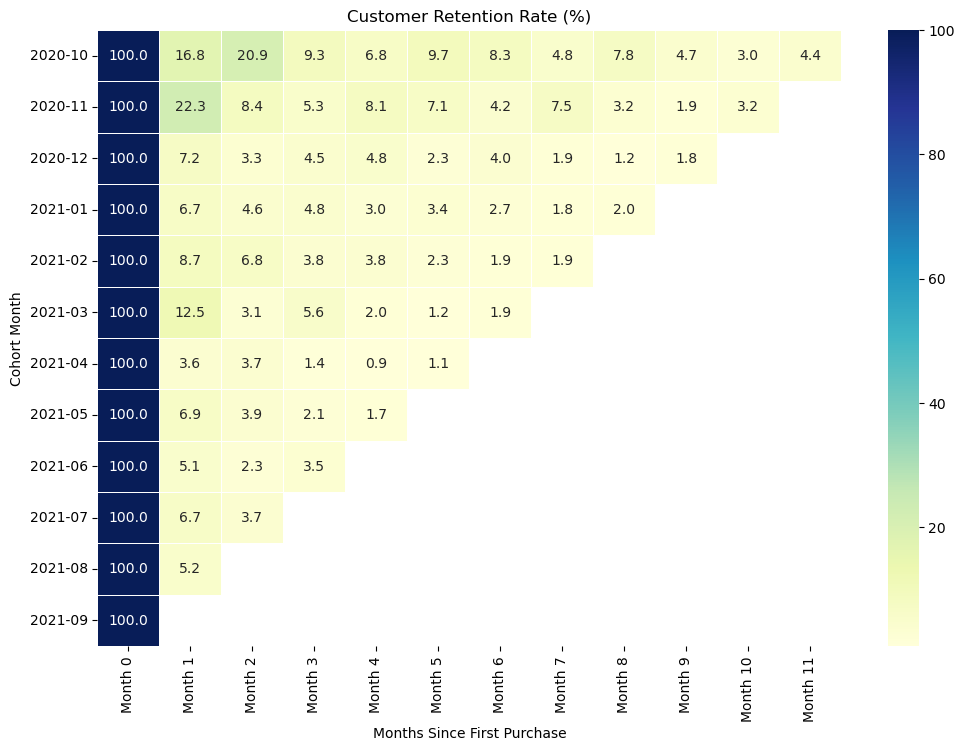

In [13]:
plt.figure(figsize=(12,8))

sns.heatmap(
    retention,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Customer Retention Rate (%)")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")

plt.show()

In [ ]:
retention.to_csv("../data/retention_percentage.csv")